# Visualisation — EEG x ANN layer alignment (sub-01)

Reads the averaged results (`alignment_sub-01.csv`) and per-seed results
(`alignment_sub-01_seeds.csv`) from `03_run_alignment.py`, and draws:
1. mean test-loss heatmap (layer x time window), best window of each layer boxed,
2. the same, normalised within each layer,
3. **continuous peak alignment time vs. network depth** (loss-weighted centre of
   mass over time), with error bars across seeds and a correlation per network,
4. a printed best-window stability table.

Run the multi-seed `03_run_alignment.py` first so both CSV files exist.

In [1]:
import csv, os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

RES_DIR  = os.path.expanduser("~/things_eeg/results")
AGG_CSV  = os.path.join(RES_DIR, "alignment_sub-01.csv")        # averaged over seeds
SEED_CSV = os.path.join(RES_DIR, "alignment_sub-01_seeds.csv")  # one row per seed

NETWORKS = {
    "RN50":     ["RN50__stem","RN50__layer1","RN50__layer2","RN50__layer3","RN50__layer4","RN50__attnpool"],
    "ViT-B-16": [f"ViT-B-16__block{i}" for i in (2,4,6,8,10,12)],
    "ViT-L-14": [f"ViT-L-14__block{i}" for i in (4,8,12,16,20,24)],
}
TARGET_ORDER = NETWORKS["RN50"] + NETWORKS["ViT-B-16"] + NETWORKS["ViT-L-14"]
WIN_ORDER = ["baseline","0_100","100_200","200_300","300_400","400_500","500_600","600_700","700_800"]
POST = WIN_ORDER[1:]
WIN_CENTER = {"0_100":50,"100_200":150,"200_300":250,"300_400":350,
              "400_500":450,"500_600":550,"600_700":650,"700_800":750}
CENTERS = np.array([WIN_CENTER[w] for w in POST])               # ms per post window

mean_loss = {}
with open(AGG_CSV) as f:
    for r in csv.DictReader(f):
        mean_loss[(r["target"], r["window"])] = float(r["test_loss"])

seed_loss = defaultdict(dict)
HAVE_SEEDS = os.path.exists(SEED_CSV)
if HAVE_SEEDS:
    with open(SEED_CSV) as f:
        for r in csv.DictReader(f):
            seed_loss[int(r["seed"])][(r["target"], r["window"])] = float(r["test_loss"])
ALL_SEEDS = sorted(seed_loss)

def weighted_peak_time(losses_post, baseline_loss):
    """Continuous peak time: centre of mass over windows, weighted by how much
    each window beats the pre-stimulus baseline (lower loss => more weight).
    Uses the whole loss curve, not just the single best window."""
    w = np.clip(baseline_loss - np.asarray(losses_post), 0, None)
    return float((w * CENTERS).sum() / w.sum()) if w.sum() > 0 else np.nan

def pearson(x, y):
    x = np.asarray(x, float) - np.mean(x); y = np.asarray(y, float) - np.mean(y)
    d = np.sqrt((x*x).sum() * (y*y).sum())
    return float((x*y).sum() / d) if d > 0 else np.nan

print("layers:", len(TARGET_ORDER), "| seeds:", ALL_SEEDS if HAVE_SEEDS else "none found")

layers: 18 | seeds: [0, 1, 2, 3, 4]


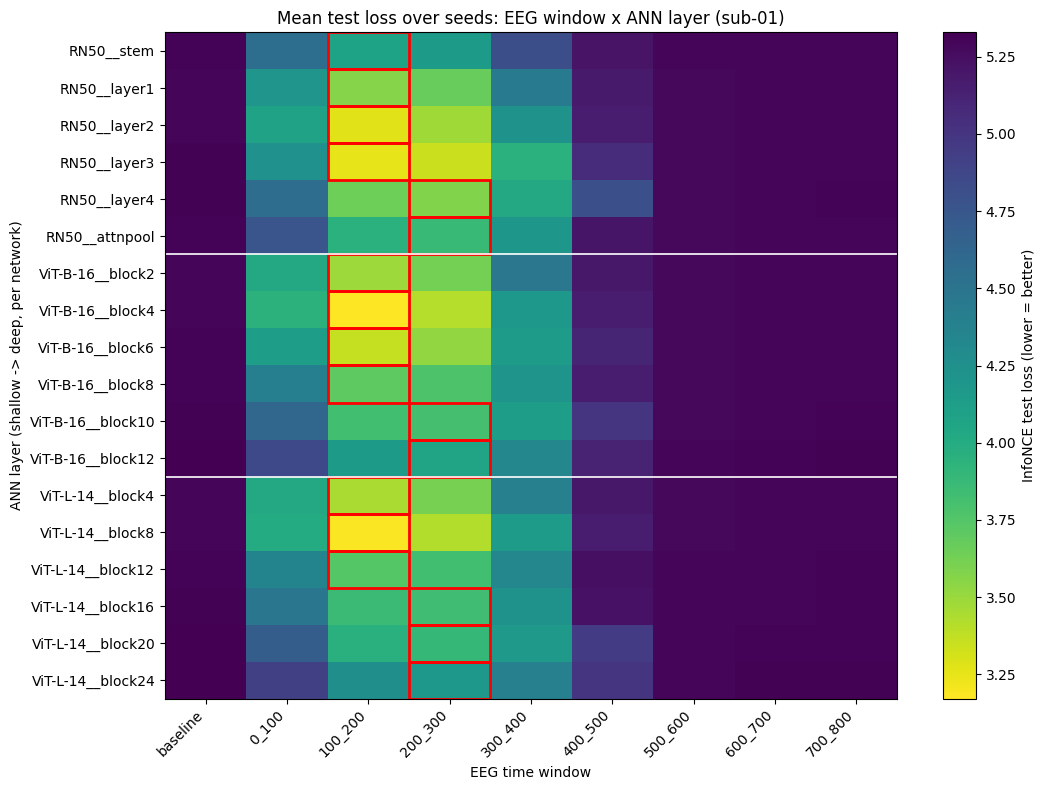

In [2]:
# Figure 1 — mean test loss heatmap, each layer's best window boxed
M = np.array([[mean_loss[(t, w)] for w in WIN_ORDER] for t in TARGET_ORDER])
fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(M, aspect="auto", cmap="viridis_r")
ax.set_xticks(range(len(WIN_ORDER))); ax.set_xticklabels(WIN_ORDER, rotation=45, ha="right")
ax.set_yticks(range(len(TARGET_ORDER))); ax.set_yticklabels(TARGET_ORDER)
ax.set_xlabel("EEG time window"); ax.set_ylabel("ANN layer (shallow -> deep, per network)")
ax.set_title("Mean test loss over seeds: EEG window x ANN layer (sub-01)")
plt.colorbar(im, label="InfoNCE test loss (lower = better)")
for i, t in enumerate(TARGET_ORDER):
    j = 1 + int(np.argmin([mean_loss[(t, w)] for w in POST]))
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="red", lw=2))
for y in (5.5, 11.5):
    ax.axhline(y, color="white", lw=1.2)
plt.tight_layout(); plt.savefig(os.path.join(RES_DIR, "heatmap_sub-01.png"), dpi=150); plt.show()

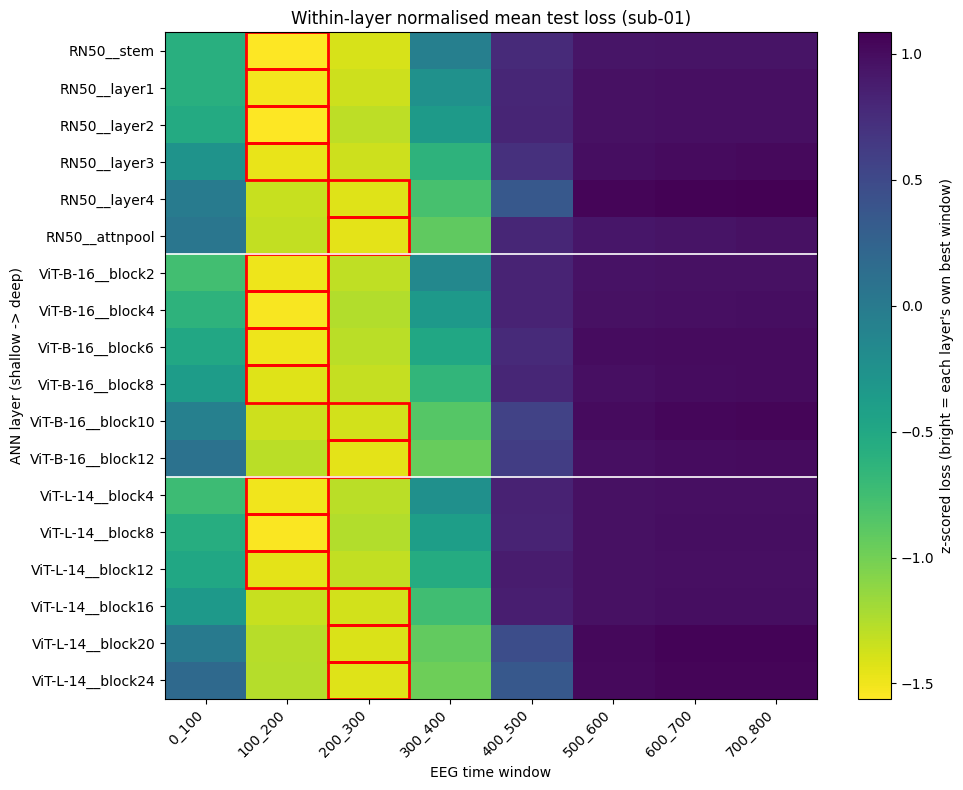

In [3]:
# Figure 2 — normalised within each layer
P = np.array([[mean_loss[(t, w)] for w in POST] for t in TARGET_ORDER])
Z = (P - P.mean(1, keepdims=True)) / P.std(1, keepdims=True)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(Z, aspect="auto", cmap="viridis_r")
ax.set_xticks(range(len(POST))); ax.set_xticklabels(POST, rotation=45, ha="right")
ax.set_yticks(range(len(TARGET_ORDER))); ax.set_yticklabels(TARGET_ORDER)
ax.set_xlabel("EEG time window"); ax.set_ylabel("ANN layer (shallow -> deep)")
ax.set_title("Within-layer normalised mean test loss (sub-01)")
plt.colorbar(im, label="z-scored loss (bright = each layer's own best window)")
for i, t in enumerate(TARGET_ORDER):
    j = int(np.argmin([mean_loss[(t, w)] for w in POST]))
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="red", lw=2))
for y in (5.5, 11.5):
    ax.axhline(y, color="white", lw=1.2)
plt.tight_layout(); plt.savefig(os.path.join(RES_DIR, "heatmap_norm_sub-01.png"), dpi=150); plt.show()

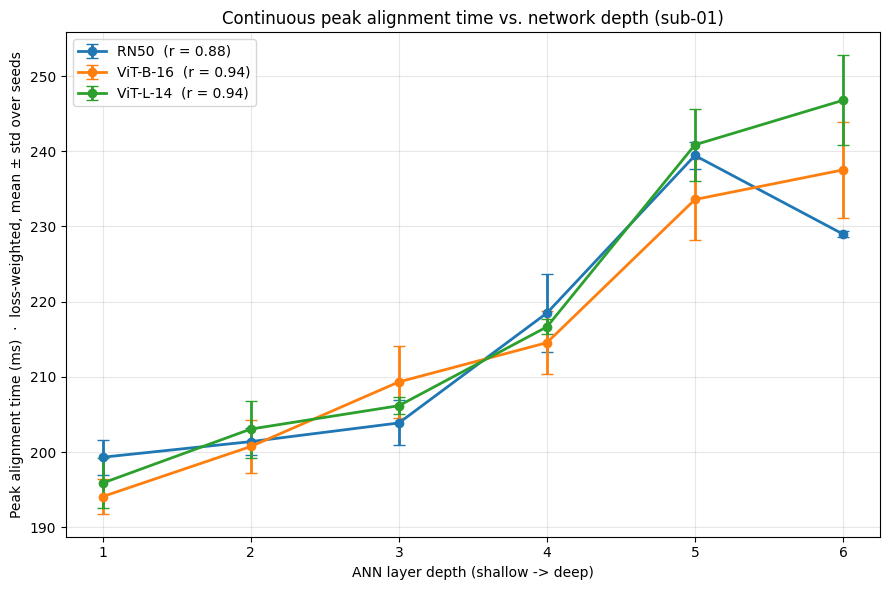

In [4]:
# Figure 3 — CONTINUOUS peak alignment time vs depth (loss-weighted centre of mass).
# Per layer & seed, peak time = baseline-improvement-weighted average of window times.
# A rising line = deeper layers peak later; small error bars = stable across seeds.
# r = Pearson correlation between depth and peak time (across all seeds & layers).
assert HAVE_SEEDS, "Run the multi-seed 03_run_alignment.py first (no per-seed file found)."

fig, ax = plt.subplots(figsize=(9, 6))
colors = {"RN50": "tab:blue", "ViT-B-16": "tab:orange", "ViT-L-14": "tab:green"}
for net, layers in NETWORKS.items():
    depth_mean, peak_mean, peak_std = [], [], []
    all_d, all_p = [], []                       # every (depth, peak) point, for the correlation
    for d, t in enumerate(layers, start=1):
        peaks = []
        for s in ALL_SEEDS:
            base = seed_loss[s][(t, "baseline")]
            losses = [seed_loss[s][(t, w)] for w in POST]
            pk = weighted_peak_time(losses, base)
            if not np.isnan(pk):
                peaks.append(pk); all_d.append(d); all_p.append(pk)
        depth_mean.append(d); peak_mean.append(np.mean(peaks)); peak_std.append(np.std(peaks))
    r = pearson(all_d, all_p)
    ax.errorbar(depth_mean, peak_mean, yerr=peak_std, marker="o", capsize=4, lw=2,
                color=colors[net], label=f"{net}  (r = {r:.2f})")

ax.set_xlabel("ANN layer depth (shallow -> deep)")
ax.set_ylabel("Peak alignment time (ms)  ·  loss-weighted, mean ± std over seeds")
ax.set_title("Continuous peak alignment time vs. network depth (sub-01)")
ax.set_xticks(range(1, 7)); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(RES_DIR, "peaktime_vs_depth_sub-01.png"), dpi=150); plt.show()

In [5]:
# Stability table — discrete best window per seed, and how often the seeds agree.
if HAVE_SEEDS:
    print(f"{'layer':24s} {'best window per seed':45s} mode (agreement)")
    print("-" * 90)
    for t in TARGET_ORDER:
        bps = [POST[int(np.argmin([seed_loss[s][(t, w)] for w in POST]))] for s in ALL_SEEDS]
        vals, counts = np.unique(bps, return_counts=True)
        mode = vals[int(np.argmax(counts))]; agree = counts.max() / len(ALL_SEEDS)
        print(f"{t:24s} {str(bps):45s} {mode} ({agree*100:.0f}%)")
else:
    print("No per-seed file found - run the multi-seed 03_run_alignment.py first.")

layer                    best window per seed                          mode (agreement)
------------------------------------------------------------------------------------------
RN50__stem               ['100_200', '100_200', '100_200', '100_200', '200_300'] 100_200 (80%)
RN50__layer1             ['100_200', '100_200', '100_200', '100_200', '100_200'] 100_200 (100%)
RN50__layer2             ['100_200', '100_200', '100_200', '100_200', '100_200'] 100_200 (100%)
RN50__layer3             ['100_200', '100_200', '100_200', '100_200', '100_200'] 100_200 (100%)
RN50__layer4             ['200_300', '200_300', '200_300', '200_300', '200_300'] 200_300 (100%)
RN50__attnpool           ['200_300', '200_300', '200_300', '200_300', '200_300'] 200_300 (100%)
ViT-B-16__block2         ['100_200', '100_200', '100_200', '100_200', '100_200'] 100_200 (100%)
ViT-B-16__block4         ['100_200', '100_200', '100_200', '100_200', '100_200'] 100_200 (100%)
ViT-B-16__block6         ['100_200', '100_200', '100_2